In [1]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph,START,END,add_messages
from typing import TypedDict,List,Annotated
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage,HumanMessage,RemoveMessage
from langchain_core.prompts import PromptTemplate
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages.utils import count_tokens_approximately,trim_messages


In [2]:
load_dotenv()

model = ChatOpenAI()

In [3]:
class MessageState(TypedDict):

    messages : Annotated[List[BaseMessage],add_messages]
    summary : str

In [14]:
def chat_node(state: MessageState) -> dict:

    messages = []

    summary_text = state.get("summary", "")

    if summary_text:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [15]:
def summary(state:MessageState)->dict:

    existing_summary = state.get("summary", "")

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [16]:
def summarize_conditions(state:MessageState):

    messages = state['messages']

    if len(messages)>6:
        return 'summary'
    else:
        return END

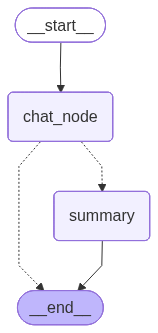

In [17]:
graph = StateGraph(MessageState)

graph.add_node('chat_node',chat_node)
graph.add_node('summary',summary)

graph.add_edge(START,'chat_node')
graph.add_conditional_edges('chat_node',summarize_conditions,{'summary':'summary',END:END})
graph.add_edge('summary',END)

checkpointer = InMemorySaver()

chatbot = graph.compile(checkpointer=checkpointer)

chatbot

In [18]:
config = {'configurable':{'thread_id':'thread-1'}}

chatbot.invoke({'messages':[HumanMessage(content='My name is khan')]},config=config)
chatbot.invoke({'messages':[HumanMessage(content='I love Python')]},config=config)
chatbot.invoke({'messages':[HumanMessage(content='I am data expert')]},config=config)

[HumanMessage(content='My name is khan', additional_kwargs={}, response_metadata={}, id='038b2159-0892-4317-a9e0-a529b8253519')]
[HumanMessage(content='My name is khan', additional_kwargs={}, response_metadata={}, id='038b2159-0892-4317-a9e0-a529b8253519'), AIMessage(content='Hello Khan, nice to meet you. How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 12, 'total_tokens': 27, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DEqewPmbrfVpmuVsY5J51164HVTE8', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ca43f-d48b-71e1-b912-de8f16c9ee82-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'

{'messages': [HumanMessage(content='My name is khan', additional_kwargs={}, response_metadata={}, id='038b2159-0892-4317-a9e0-a529b8253519'),
  AIMessage(content='Hello Khan, nice to meet you. How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 12, 'total_tokens': 27, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DEqewPmbrfVpmuVsY5J51164HVTE8', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ca43f-d48b-71e1-b912-de8f16c9ee82-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 15, 'total_tokens': 27, 'input_token_details': {'audio': 0, 'cache_read': 0}, 

In [26]:
chatbot.invoke({'messages':[HumanMessage(content='I am a quick learner')]},config=config)

[{'role': 'system', 'content': "Conversation summary:\nThe conversation above was about the user, Khan, expressing his love for Python, stating that he is a data expert, and sharing his interest in learning Artificial Intelligence. I acknowledged his enthusiasm for Python and AI, highlighting Python's versatility in data analysis and its popularity in AI and machine learning applications."}, HumanMessage(content='I Love AI and I am learning it', additional_kwargs={}, response_metadata={}, id='5a8a841d-c8d1-4ac0-b949-483f4138f9b3'), AIMessage(content="That's fantastic! Artificial Intelligence is a fascinating and rapidly growing field. Python is a popular choice for AI and machine learning projects due to its flexibility and extensive libraries like TensorFlow, PyTorch, and scikit-learn. Keep up the great work in your AI learning journey! If you have any questions or need assistance, feel free to ask.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_

{'messages': [HumanMessage(content='I am a quick learner', additional_kwargs={}, response_metadata={}, id='837309db-2c9d-426a-8b86-cb7ab8664819'),
  AIMessage(content="That's wonderful to hear, Khan! Being a quick learner will definitely be a valuable asset as you delve deeper into the world of Artificial Intelligence. With your enthusiasm, passion for AI, and Python skills, your ability to pick up new concepts efficiently will undoubtedly help you excel in your journey to becoming a great AI engineer. Keep up the fantastic work, and don't hesitate to explore new challenges and opportunities for growth in the field of AI!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 88, 'prompt_tokens': 352, 'total_tokens': 440, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'ope

In [28]:
chatbot.invoke({'messages':[HumanMessage(content='Tell me something about user')]},config=config)

[{'role': 'system', 'content': "Conversation summary:\nIn the recent conversation, Khan revealed his dream of becoming a top AI engineer, showcasing his ambitious goal and passion for Artificial Intelligence. He emphasized his quick learning ability, indicating a strong potential for grasping AI concepts efficiently and effectively advancing in the field. Khan's proactive attitude toward learning and dedication to mastering Python and AI technologies will undoubtedly propel him closer to achieving his dream of becoming a prominent figure in the AI engineering domain. With his determination and relentless pursuit of knowledge, Khan is well on his way to making significant strides in the exciting realm of Artificial Intelligence."}, HumanMessage(content='I am a quick learner', additional_kwargs={}, response_metadata={}, id='837309db-2c9d-426a-8b86-cb7ab8664819'), AIMessage(content="That's wonderful to hear, Khan! Being a quick learner will definitely be a valuable asset as you delve deep

{'messages': [HumanMessage(content='I am a quick learner', additional_kwargs={}, response_metadata={}, id='837309db-2c9d-426a-8b86-cb7ab8664819'),
  AIMessage(content="That's wonderful to hear, Khan! Being a quick learner will definitely be a valuable asset as you delve deeper into the world of Artificial Intelligence. With your enthusiasm, passion for AI, and Python skills, your ability to pick up new concepts efficiently will undoubtedly help you excel in your journey to becoming a great AI engineer. Keep up the fantastic work, and don't hesitate to explore new challenges and opportunities for growth in the field of AI!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 88, 'prompt_tokens': 352, 'total_tokens': 440, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'ope

In [29]:
snap = chatbot.get_state(config)
for m in snap.values['messages']:
    print(f"-{m.__class__.__name__} : {m.content}")

-HumanMessage : I am a quick learner
-AIMessage : That's wonderful to hear, Khan! Being a quick learner will definitely be a valuable asset as you delve deeper into the world of Artificial Intelligence. With your enthusiasm, passion for AI, and Python skills, your ability to pick up new concepts efficiently will undoubtedly help you excel in your journey to becoming a great AI engineer. Keep up the fantastic work, and don't hesitate to explore new challenges and opportunities for growth in the field of AI!
-HumanMessage : Tell me something about user
-AIMessage : In the recent conversation, Khan shared his dream of becoming a top AI engineer, highlighting his ambitious aspirations and passion for Artificial Intelligence. He emphasized his quick learning ability, indicating a strong potential for grasping AI concepts efficiently and effectively advancing in the field. Khan's proactive attitude toward learning and dedication to mastering Python and AI technologies will undoubtedly propel